In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(
    "C:/Users/LENOVO/ironhack/lab-eda-univariate/lab-eda-univariate/amz_uk_price_prediction_dataset.csv"
)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [4]:
df.head()


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [5]:
df.shape


(2443651, 9)

## Part 1: Analysing Best-Seller Trends Across Product Categories

This section examines the relationship between product category and best-seller status. Both `category` and `isBestSeller` are categorical variables. A crosstab will be used to count best-selling and non-best-selling products within each category. Proportions will then be calculated because the product categories contain different numbers of products.


In [6]:
df[["category", "isBestSeller"]].head()

,category,isBestSeller
0,Hi-Fi Speakers,False
1,Hi-Fi Speakers,True
2,Hi-Fi Speakers,False
3,Hi-Fi Speakers,False
4,Hi-Fi Speakers,False


However, we cannot conclude that the best-seller proportion is 20%, because .head() only displays the first five rows—not the complete category.

In [7]:
best_seller_crosstab = pd.crosstab(
    index=df["category"],
    columns=df["isBestSeller"]
)

best_seller_crosstab

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


### Crosstab Analysis: Product Category and Best-Seller Status

The crosstab compares the number of best-selling (`True`) and non-best-selling (`False`) product listings within each of the 296 product categories.

The displayed results show that non-best-selling products greatly outnumber best-selling products in every visible category. For example, the `Women` category contains 17,559 non-best-selling products and 213 best-selling products. `Women's Sports & Outdoor Shoes` contains 1,939 non-best sellers and 20 best sellers, while `eBook Readers & Accessories` contains 246 products but no best sellers.

Although `Women` has the largest visible number of best sellers, this does not necessarily mean that it has the highest best-seller prevalence because it also contains a much larger number of products. Best-seller proportions must therefore be calculated for each category to make a fair comparison between categories of different sizes.


In [8]:
best_seller_proportions = pd.crosstab(
    index=df["category"],
    columns=df["isBestSeller"],
    normalize="index"
)

best_seller_proportions

isBestSeller,False,True
category,,
3D Printers,0.995968,0.004032
3D Printing & Scanning,0.999508,0.000492
Abrasive & Finishing Products,0.980000,0.020000
Action Cameras,0.999411,0.000589
Adapters,0.988189,0.011811
...,...,...
Wind Instruments,0.972000,0.028000
Window Treatments,0.979079,0.020921
Women,0.988015,0.011985


In [9]:
best_seller_proportions = pd.crosstab(
    index=df["category"],
    columns=df["isBestSeller"],
    normalize="index"
)

best_seller_proportions_sorted = (
    best_seller_proportions[True]
    .sort_values(ascending=False)
)

(
    best_seller_proportions_sorted
    .head(10)
    .mul(100)
    .round(2)
)

category
Grocery                           5.81
Smart Home Security & Lighting    5.77
Health & Personal Care            5.77
Mobile Phone Accessories          4.25
Power & Hand Tools                3.53
Billiard, Snooker & Pool          3.21
Pet Supplies                      3.02
Home Brewing & Wine Making        2.85
Wind Instruments                  2.80
Mirrors                           2.80
Name: True, dtype: float64

### Best-Seller Prevalence Across Product Categories

Best-seller proportions were calculated using **all 296 product categories** and sorted from the highest to the lowest. For readability and a clearer comparison, only the **ten categories with the highest best-seller proportions** are displayed. Therefore, the analysis was not limited to these ten categories; they represent only the highest-ranking results from the complete analysis.

`Grocery` has the highest best-seller proportion at **5.81%**, followed closely by `Smart Home Security & Lighting` and `Health & Personal Care`, both at **5.77%**. `Mobile Phone Accessories` follows at **4.25%**, while the remaining categories in the displayed top ten range from **2.80% to 3.53%**.

Although these categories have the highest best-seller prevalence, the percentages remain relatively low. Even in the leading category, fewer than 6% of product listings are classified as best sellers.

The top-ten presentation highlights the categories where best-seller status is most prevalent but does not show the complete distribution across all categories. The full crosstab containing all 296 categories will therefore be retained for the Chi-square test to determine whether product category and best-seller status are significantly associated.


### Chi-Square Test of Independence

A Chi-square test of independence is used to determine whether there is a statistically significant association between product category and best-seller status.

* **Null hypothesis ((H_0))**: Product category and best-seller status are independent.
* **Alternative hypothesis ((H_1))**: Product category and best-seller status are associated.

A significance level of 0.05 will be used. If the p-value is less than 0.05, the null hypothesis will be rejected.


In [10]:
import sys

print(sys.executable)

C:\Users\LENOVO\anaconda3\python.exe


In [11]:
import scipy

print(scipy.__version__)

1.16.3


In [12]:
from scipy.stats import chi2_contingency

chi2_statistic, p_value, degrees_of_freedom, expected_frequencies = (
    chi2_contingency(best_seller_crosstab)
)

print("Chi-square statistic:", chi2_statistic)
print("P-value:", p_value)
print("Degrees of freedom:", degrees_of_freedom)

Chi-square statistic: 36540.20270061387
P-value: 0.0
Degrees of freedom: 295


### Interpretation of the Chi-Square Test

The Chi-square test produced a statistic of **36,540.20**, with **295 degrees of freedom** and a p-value reported by Python as `0.0`

The reported p-value does not mean that the probability is mathematically zero. It means that the p-value is extremely small and below Python’s standard numerical display precision. It can therefore be reported as **(p < 0.001)**. If the p-value is low, the null hypothesis must go(that is rejected).

Because the p-value is below the significance level of 0.05, the null hypothesis is rejected. There is statistically significant evidence of an association between product category and best-seller status:

[
\chi^2(295)=36{,}540.20,\quad p<0.001
]

This indicates that best-seller status is not distributed independently across the 296 product categories. However, the Chi-square test does not show the strength of the association or prove that product category causes a product to become a best seller. Cramér’s V will therefore be calculated next to measure the strength of the relationship.


In [13]:
from scipy.stats.contingency import association

cramers_v = association(
    best_seller_crosstab,
    method="cramer"
)

print("Cramér's V:", cramers_v)

Cramér's V: 0.1222829439760564


### Interpretation of Cramér’s V

Cramér’s V was calculated to measure the strength of the association between product category and best-seller status.

The result was:

[
V = 0.122
]

Because Cramér’s V ranges from 0 to 1, a value of approximately **0.12** indicates a **weak association** between product category and best-seller status.

This complements the Chi-square result. Although the Chi-square test found a statistically significant association ((p < 0.001)), Cramér’s V shows that the practical strength of this relationship is weak. The very large number of product listings in the dataset may allow relatively small differences between categories to become statistically significant.

Therefore, product category is associated with best-seller status, but category alone does not strongly explain whether a product will be a best seller. Other factors—such as price, rating, number of reviews, brand, product quality and marketing—may also influence best-seller status.


### Stacked Bar Chart of Best-Seller Status

The following 100% stacked bar chart visualises the proportions of best-selling and non-best-selling products within the ten categories with the highest best-seller prevalence. Although all 296 categories were included in the statistical analysis, only the leading ten are displayed to keep the chart readable.

In [14]:
top_10_categories = best_seller_proportions_sorted.head(10).index

top_10_proportions = (
    best_seller_proportions
    .loc[top_10_categories]
    .mul(100)
)

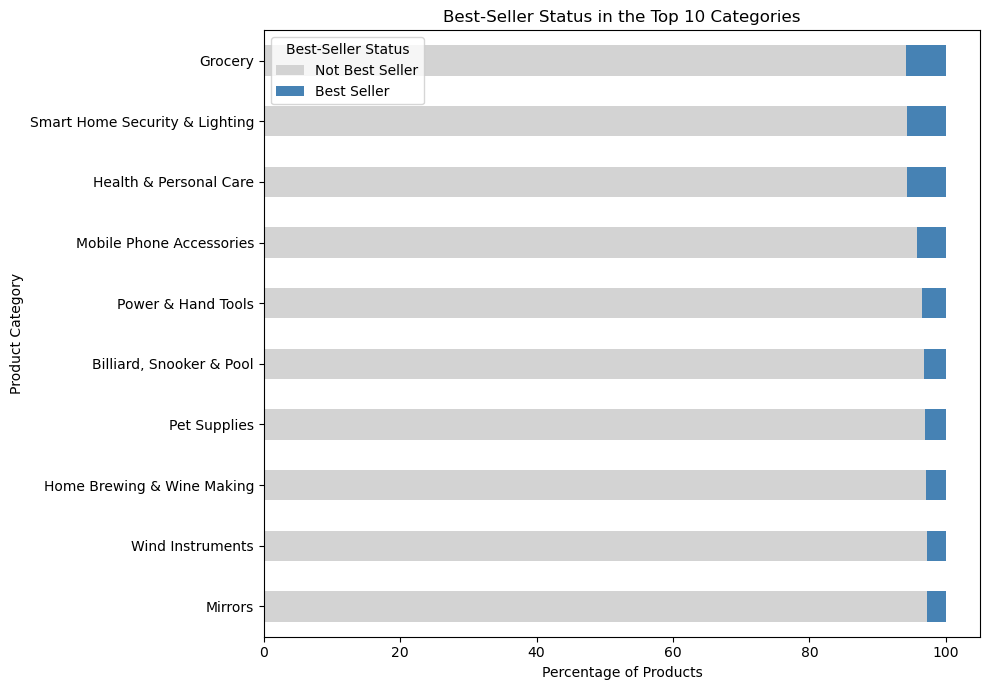

In [15]:
top_10_proportions.plot(
    kind="barh",
    stacked=True,
    figsize=(10, 7),
    color=["lightgray", "steelblue"]
)

plt.title("Best-Seller Status in the Top 10 Categories")
plt.xlabel("Percentage of Products")
plt.ylabel("Product Category")
plt.legend(
    title="Best-Seller Status",
    labels=["Not Best Seller", "Best Seller"]
)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Interpretation of the Stacked Bar Chart

The 100% stacked bar chart compares best-selling and non-best-selling products within the ten categories that recorded the highest best-seller proportions. The proportions were originally calculated across all 296 categories, but only the top ten are displayed to maintain readability.

The grey sections dominate every bar, showing that most product listings in each category are not best sellers. `Grocery` has the largest visible best-seller proportion at 5.81%, followed closely by `Smart Home Security & Lighting` and `Health & Personal Care`, both at 5.77%. `Mobile Phone Accessories` follows at 4.25%, while the remaining displayed categories have proportions between 2.80% and 3.53%.

Even among these leading categories, fewer than 6% of listings are classified as best sellers. The relatively small differences between the blue sections support the Cramér’s V result of 0.122, which indicates that the statistically significant association between product category and best-seller status is weak.


In [16]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: £{Q1:.2f}")
print(f"Q3: £{Q3:.2f}")
print(f"IQR: £{IQR:.2f}")
print(f"Lower boundary: £{lower_bound:.2f}")
print(f"Upper boundary: £{upper_bound:.2f}")

Q1: £9.99
Q3: £45.99
IQR: £36.00
Lower boundary: £-44.01
Upper boundary: £99.99


In [17]:
price_outliers = df[
    (df["price"] < lower_bound) |
    (df["price"] > upper_bound)
]

print("Number of price outliers:", len(price_outliers))

Number of price outliers: 327688


In [18]:
df_no_price_outliers = df[
    (df["price"] >= lower_bound) &
    (df["price"] <= upper_bound)
].copy()

In [19]:
print("Original products:", df.shape[0])
print("Products after filtering:", df_no_price_outliers.shape[0])
print("Products removed:", df.shape[0] - df_no_price_outliers.shape[0])

Original products: 2443651
Products after filtering: 2115963
Products removed: 327688


In [20]:
top_20_categories = (
    df_no_price_outliers["category"]
    .value_counts()
    .head(20)
    .index
)

top_20_categories

Index(['Sports & Outdoors', 'Beauty', 'Bath & Body',
       'Manicure & Pedicure Products',
       'Handmade Clothing, Shoes & Accessories', 'Make-up', 'Skin Care',
       'Hair Care', 'Birthday Gifts', 'Handmade Gifts', 'Handmade Home Décor',
       'Luggage and travel gear', 'Women', 'Fragrances',
       'Handmade Kitchen & Dining', 'Handmade Artwork',
       'Handmade Home & Kitchen Products', 'Handmade Jewellery', 'Men',
       'Baby'],
      dtype='object', name='category')

In [21]:
top_20_price_df = df_no_price_outliers[
    df_no_price_outliers["category"].isin(top_20_categories)
]

### Price Distribution Across the Top 20 Product Categories

The violin plot below compares the price distributions of the 20 product categories with the largest numbers of listings. The analysis uses the filtered DataFrame after removing price outliers with the IQR method. Only the top 20 categories are displayed to maintain readability, although all categories are retained for the separate median-price comparison.

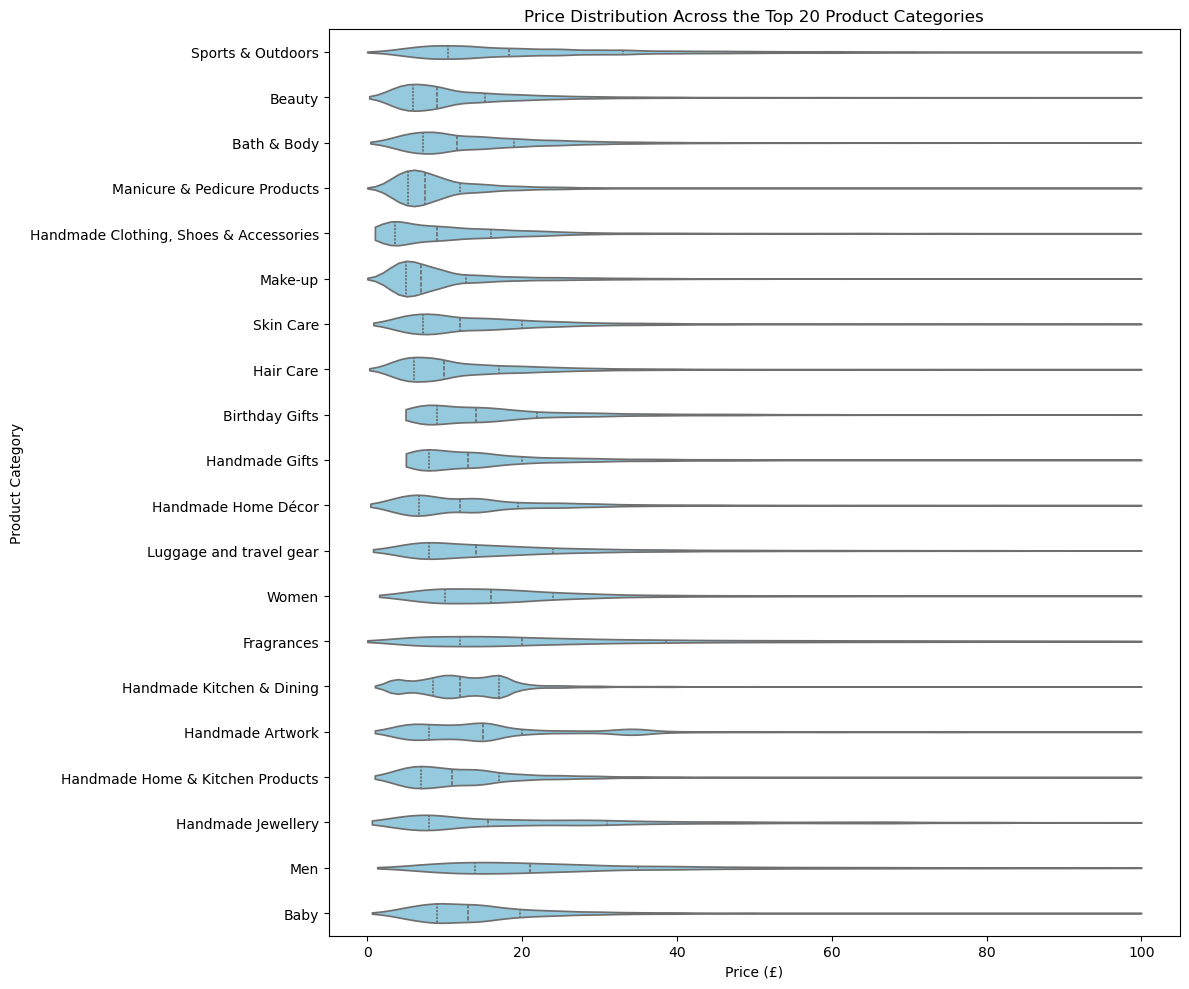

In [22]:
plt.figure(figsize=(12, 10))

sns.violinplot(
    data=top_20_price_df,
    x="price",
    y="category",
    order=top_20_categories,
    inner="quartile",
    cut=0,
    color="skyblue"
)

plt.title("Price Distribution Across the Top 20 Product Categories")
plt.xlabel("Price (£)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

### Interpretation of the Price Distributions

The violin plot compares the price distributions of the 20 product categories with the largest numbers of listings after global price outliers were removed using the IQR method.

Most categories have their widest sections below approximately **£20**, indicating that lower-priced products are more common. Categories such as `Beauty`, `Manicure & Pedicure Products`, `Make-up` and `Hair Care` are particularly concentrated at the lower end of the price range. In contrast, `Men`, `Handmade Kitchen & Dining`, `Handmade Artwork`, `Women` and `Luggage and travel gear` appear to have comparatively higher central price positions and wider price spreads.

Most distributions are positively skewed, with a greater concentration of lower-priced products and long, narrow tails extending towards higher prices. Some categories, including `Sports & Outdoors`, `Fragrances`, `Handmade Artwork` and `Men`, contain relatively high-priced products extending considerably beyond their main concentrations.

The global price outliers above approximately **£99.99** were removed before constructing the plot. However, some prices remaining near the upper end may still be unusual within their individual categories. These are not automatically global outliers and would require category-specific IQR calculations or boxplots for formal identification.

Only the 20 most frequently listed categories are displayed for readability. This plot therefore describes their price distributions but does not determine which of all 296 categories has the highest median price. A separate median calculation using every category is required for that question.


In [23]:
median_price_by_category = (
    df_no_price_outliers
    .groupby("category")["price"]
    .median()
    .sort_values(ascending=False)
)

median_price_by_category.head(10)


category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64

In [24]:
highest_median_category = median_price_by_category.index[0]
highest_median_price = median_price_by_category.iloc[0]
 
print("Category with the highest median price:", highest_median_category)
print(f"Highest median price: £{highest_median_price:.2f}")

Category with the highest median price: Desktop PCs
Highest median price: £74.00


### Product Category with the Highest Median Price

Median prices were calculated for all product categories using the dataset after global price outliers were removed. `Desktop PCs` has the highest median price at **£74.00**, followed by `Boxing Shoes` at **£69.79** and `Tablets` at **£69.00**.

Technology-related categories feature prominently among the highest median prices. `Graphics Cards`, `Motherboards`, `Digital Frames` and `Streaming Clients` all appear within the top ten. This suggests that products in specialised computing and electronic categories generally command higher typical prices.

The median is used because it is less affected by unusually expensive products than the mean. The calculation included every product category; only the ten highest results are displayed for readability. Although global price outliers above the IQR boundary were removed, category-specific unusual prices may still remain and would require separate within-category analysis to identify.


In [25]:
top_10_count_categories = (
    df_no_price_outliers["category"]
    .value_counts()
    .head(10)
    .index
)


In [26]:
top_10_average_prices = (
    df_no_price_outliers[
        df_no_price_outliers["category"].isin(top_10_count_categories)
    ]
    .groupby("category", as_index=False)["price"]
    .mean()
    .sort_values("price", ascending=False)
)

top_10_average_prices

,category,price
9,Sports & Outdoors,25.172065
2,Birthday Gifts,18.600195
5,Handmade Gifts,17.395112
8,Skin Care,15.654722
0,Bath & Body,14.678683
3,Hair Care,13.461408
4,"Handmade Clothing, Shoes & Accessories",12.958639
1,Beauty,12.523480
6,Make-up,10.612918
7,Manicure & Pedicure Products,10.231825


### Average Price Across the Top 10 Product Categories

The bar chart below compares the average product prices of the ten categories with the largest numbers of listings. The categories were selected by frequency, while their average prices were calculated using the dataset after global price outliers were removed with the IQR method.

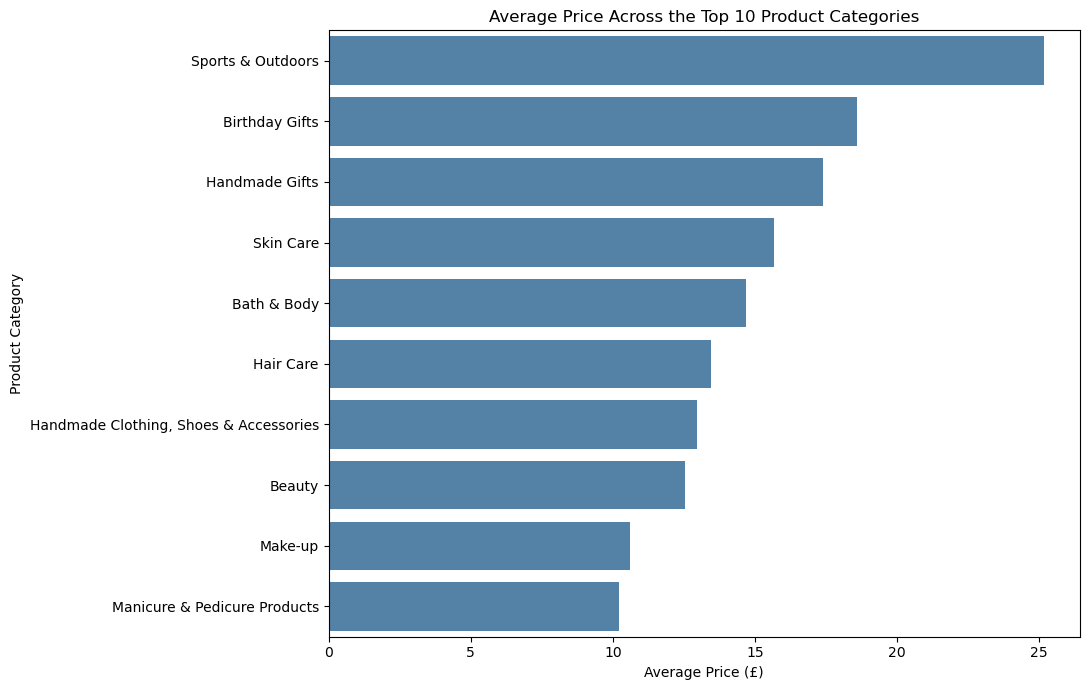

In [27]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=top_10_average_prices,
    x="price",
    y="category",
    color="steelblue"
)

plt.title("Average Price Across the Top 10 Product Categories")
plt.xlabel("Average Price (£)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

### Interpretation of Average Prices Across the Top 10 Categories

The bar chart compares the mean product prices of the ten categories with the largest numbers of listings after global price outliers were removed. `Sports & Outdoors` has the highest average price among these frequently listed categories, while `Manicure & Pedicure Products` has the lowest average price at approximately £10.

`Bath & Body` has an average price of approximately £15, followed by `Hair Care`, `Handmade Clothing, Shoes & Accessories` and `Beauty`, with average prices of approximately £12–£14. `Make-up` and `Manicure & Pedicure Products` have comparatively lower average prices.

These results show that the most frequently listed product categories do not have identical typical price levels. However, the chart covers only the ten largest categories by product count and therefore does not identify the highest average price across all 296 categories.

Global price outliers above the IQR boundary were removed before calculating these means, reducing the influence of extremely expensive products. Nevertheless, the mean can still be influenced by relatively high prices that remain within the accepted boundaries.


In [28]:
average_price_by_category = (
    df_no_price_outliers
    .groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

average_price_by_category.head(10).round(2)


category
Motherboards         68.77
Boxing Shoes         67.42
Desktop PCs          66.92
Tablets              66.55
Graphics Cards       65.10
Digital Frames       60.75
Streaming Clients    60.24
Hockey Shoes         60.09
Computer Cases       58.34
Skiing Poles         57.87
Name: price, dtype: float64

In [29]:
highest_average_category = average_price_by_category.index[0]
highest_average_price = average_price_by_category.iloc[0]

print(
    "Category with the highest average price:",
    highest_average_category
)

print(
    f"Highest average price: £{highest_average_price:.2f}"
)

Category with the highest average price: Motherboards
Highest average price: £68.77


In [30]:
top_10_rating_categories = (
    df_no_price_outliers["category"]
    .value_counts()
    .head(10)
    .index
)

In [31]:
top_10_ratings_df = df_no_price_outliers[
    (df_no_price_outliers["category"].isin(top_10_rating_categories))
    &
    (df_no_price_outliers["stars"] > 0)
].copy()

### Rating Distribution Across the Top 10 Product Categories

The boxplots below compare the distribution of recorded product ratings across the ten categories with the largest numbers of listings. Ratings of `0.00` were excluded because they represent products without a recorded customer rating rather than genuine zero-star evaluations. Global price outliers were also previously removed in accordance with the Part 2 instructions.

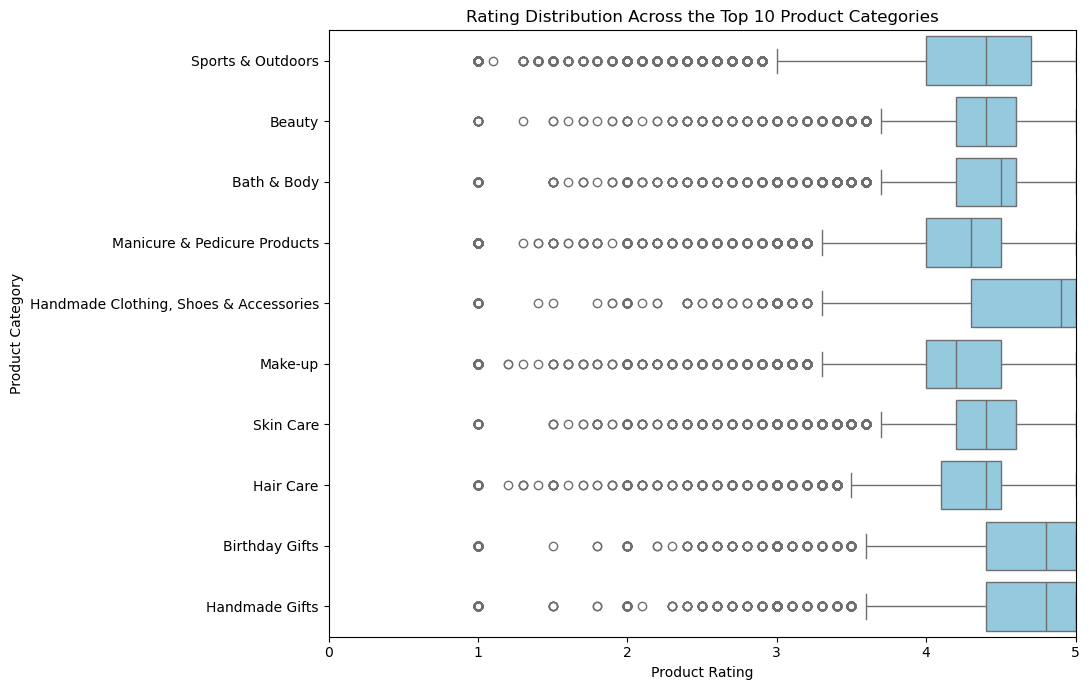

In [32]:
plt.figure(figsize=(11, 7))

sns.boxplot(
    data=top_10_ratings_df,
    x="stars",
    y="category",
    order=top_10_rating_categories,
    color="skyblue"
)

plt.title("Rating Distribution Across the Top 10 Product Categories")
plt.xlabel("Product Rating")
plt.ylabel("Product Category")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

### Interpretation of Rating Distributions Across the Top 10 Categories

The boxplots compare recorded customer ratings across the ten categories with the largest numbers of product listings. Products with a rating of `0.00` were excluded because these values represent products without a recorded rating rather than genuine zero-star reviews.

Ratings are generally concentrated at the upper end of the scale. Most category medians fall between approximately **4.3 and 4.8 stars**, indicating that a typical rated product receives a favourable customer evaluation.

Among the ten categories displayed, `Handmade Clothing, Shoes & Accessories` has the highest median customer rating, close to **5 stars**. `Birthday Gifts` and `Handmade Gifts` also have comparatively high median ratings.

Numerous potential low-rating outliers are visible below the lower whiskers in every category, with some ratings as low as approximately 1 star. These observations represent products rated considerably lower than the typical product in their category. The outliers appear particularly numerous in large categories such as `Sports & Outdoors`, `Beauty`, `Make-up` and `Hair Care`.

These low-rating outliers should not automatically be removed because they may represent genuine negative customer experiences rather than data errors. They may reduce category mean ratings, while the median remains less affected. No comparable high-rating outliers are visible because most distributions are already concentrated near the maximum possible rating of 5 stars.

This chart identifies the highest median only among the ten displayed categories. A separate calculation using all product categories is required to determine the highest median rating across the complete dataset.


median_rating_by_category = (
    df_no_price_outliers[df_no_price_outliers["stars"] > 0]
    .groupby("category")["stars"]
    .median()
    .sort_values(ascending=False)
)

median_rating_by_category.head(10)

In [33]:
# Exclude zero because it means that no rating was recorded
rated_products = df_no_price_outliers[
    df_no_price_outliers["stars"] > 0
]

# Calculate the median rating for every category
median_rating_by_category = (
    rated_products
    .groupby("category")["stars"]
    .median()
    .sort_values(ascending=False)
)

# Find the highest median rating
highest_median_rating = median_rating_by_category.max()

# Select every category with that highest median
categories_with_highest_median = median_rating_by_category[
    median_rating_by_category == highest_median_rating
]

categories_with_highest_median


category
Made in Italy Handmade    5.0
Handmade Baby Products    5.0
Handmade Artwork          5.0
Name: stars, dtype: float64

### Categories with the Highest Median Customer Rating

After excluding products with a rating of `0`, three categories share the highest median customer rating of **5.0 stars**:

- **Made in Italy Handmade**
- **Handmade Baby Products**
- **Handmade Artwork**

A median of 5.0 means that the middle rating in each of these categories is 5 stars. However, this result should be interpreted carefully because categories may contain different numbers of products and reviews. A category with relatively few rated products could achieve a median of 5.0 more easily than a category containing many rated products.

The boxplot also shows numerous low-rating outliers across the major product categories. These outliers represent products whose ratings are unusually low compared with the typical ratings in their respective categories. They should not automatically be removed because they may reflect genuine customer dissatisfaction.

## Part 3: Relationship Between Product Price and Rating

This section investigates whether product prices are related to customer ratings. Both `price` and `stars` are numerical variables. Products with zero ratings are excluded because `0.00` represents the absence of a recorded rating rather than a genuine customer evaluation. Global price outliers were previously removed using the IQR method.

In [34]:
price_rating_df = (
    df_no_price_outliers[
        df_no_price_outliers["stars"] > 0
    ][["price", "stars"]]
    .dropna()
    .copy()
)

In [35]:
pearson_correlation = price_rating_df["price"].corr(
    price_rating_df["stars"]
)

print(f"Pearson correlation: {pearson_correlation:.4f}")


Pearson correlation: 0.0067


In [36]:
from scipy.stats import pearsonr

correlation_coefficient, correlation_p_value = pearsonr(
    price_rating_df["price"],
    price_rating_df["stars"]
)

print("P-value:", correlation_p_value)

P-value: 1.0813032347780282e-12


### Pearson Correlation Between Product Price and Rating

Pearson’s correlation coefficient was calculated to measure the strength and direction of the linear relationship between product price and customer rating. Products with a rating of `0.00` were excluded because these values represent products without a recorded rating. Global price outliers were also previously removed using the IQR method.

The results were:

[
r = 0.0067,\qquad p = 1.08 \times 10^{-12}
]

The p-value is written in scientific notation and is extremely small—well below the significance level of 0.05. Therefore, the null hypothesis of no linear correlation is rejected, and the relationship is considered statistically significant.

However, the correlation coefficient of **0.0067** is extremely close to zero, indicating that the relationship is practically negligible. Product price and customer rating have almost no meaningful linear relationship: higher-priced products do not consistently receive higher ratings, and lower-priced products do not consistently receive lower ratings.

The very large number of product listings makes it possible for an extremely weak relationship to produce a very small p-value. Therefore, the relationship is statistically significant but not practically meaningful. Product price is not a useful standalone indicator of customer rating in this dataset.


In [37]:
scatter_sample = price_rating_df.sample(
    n=min(20000, len(price_rating_df)),
    random_state=42
)

### Scatterplot of Product Price and Rating

The scatterplot below visualises the relationship between customer rating and product price. A reproducible sample of up to 20,000 product listings is used to reduce overplotting and improve performance. The Pearson correlation was calculated separately using the complete filtered dataset.

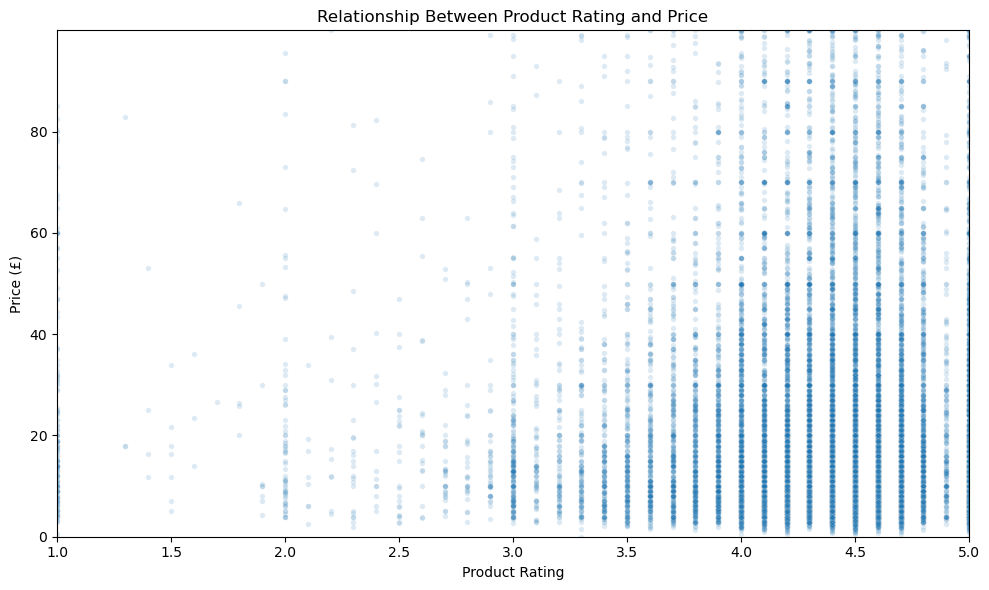

In [38]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=scatter_sample,
    x="stars",
    y="price",
    alpha=0.15,
    s=15
)

plt.title("Relationship Between Product Rating and Price")
plt.xlabel("Product Rating")
plt.ylabel("Price (£)")
plt.xlim(1, 5)
plt.ylim(0, upper_bound)
plt.tight_layout()
plt.show()

### Interpretation of the Price–Rating Scatterplot

The scatterplot shows no clear upward or downward pattern between product rating and price. Products with similar ratings occur across a wide range of prices, while products with similar prices receive different ratings. This indicates that price does not meaningfully predict customer rating.

Most observations are concentrated between approximately **4 and 5 stars** and below **£20**, showing that many rated products are relatively inexpensive and receive favourable reviews. The vertical bands occur because ratings take specific values, such as 4.0, 4.1 and 4.2, rather than every possible continuous value.

Relatively high-priced products appear across several rating levels, including prices close to the upper IQR boundary of £99.99. Global price outliers above this boundary were removed, but some remaining observations may still be unusual relative to the main low-price concentration. They are not global IQR outliers under the filtering rule used.

The absence of a visible linear trend supports the Pearson correlation result of (r=0.0067), which indicates a practically negligible relationship. Although the correlation was statistically significant because of the very large sample size, the scatterplot confirms that the relationship has almost no practical predictive value.


In [39]:
numerical_df = (
    df_no_price_outliers[
        df_no_price_outliers["stars"] > 0
    ]
    .select_dtypes(include="number")
    .copy()
)

numerical_df.columns

Index(['uid', 'stars', 'reviews', 'price', 'boughtInLastMonth'], dtype='object')

In [40]:
numerical_df = numerical_df.drop(
    columns=["uid"],
    errors="ignore"
)

In [41]:
correlation_matrix = numerical_df.corr()

correlation_matrix.round(2)

,stars,reviews,price,boughtInLastMonth
stars,1.00,0.03,0.01,0.04
reviews,0.03,1.00,-0.00,0.10
price,0.01,-0.00,1.00,-0.07
boughtInLastMonth,0.04,0.10,-0.07,1.00


### Correlation Heatmap of Numerical Variables

The heatmap below displays Pearson correlation coefficients between the numerical variables in the filtered dataset. Products without recorded ratings and global price outliers were excluded. Identifier columns were also removed because their numerical values do not represent measurable product characteristics.

In [42]:
numerical_df = numerical_df.drop(
    columns=["uid"],
    errors="ignore"
)

correlation_matrix = numerical_df.corr()

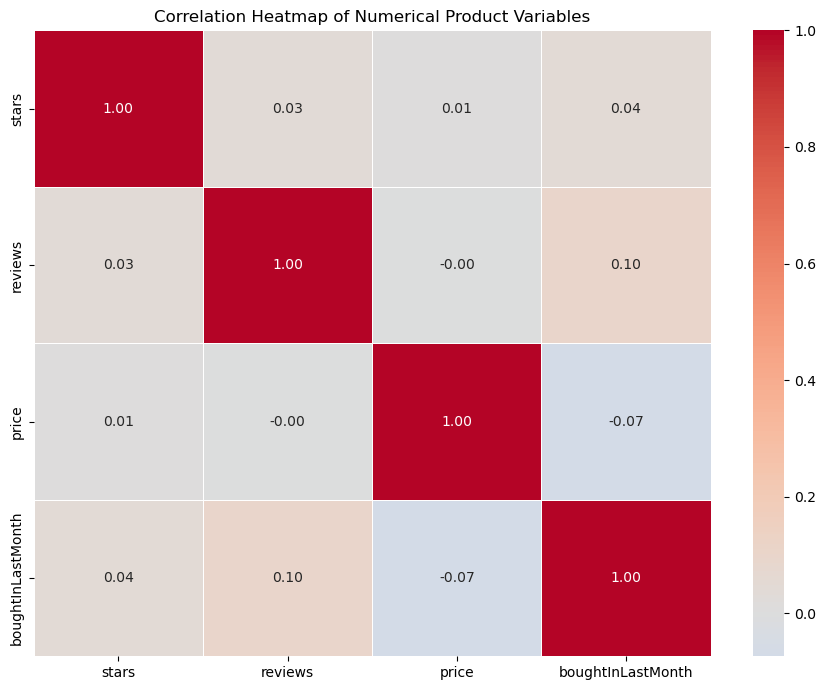

In [43]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Product Variables")
plt.tight_layout()
plt.show()


### Interpretation of the Correlation Heatmap

The heatmap shows that the numerical product variables generally have very weak linear relationships with one another. Most correlation coefficients are close to zero.

The strongest non-diagonal correlation is between `reviews` and `boughtInLastMonth`, with a coefficient of approximately **0.10**. This is a weak positive relationship, suggesting that products with more reviews may tend to have slightly more recent purchases, although the relationship is not strong.

`price` and `boughtInLastMonth` have a weak negative correlation of approximately **−0.07**, indicating that higher-priced products may be purchased slightly less frequently. However, this relationship is also too weak to have substantial predictive value.

The heatmap displays the correlation between `price` and `stars` as **0.01** because the values are rounded to two decimal places. The more precise Pearson result was **0.0067**, confirming that there is virtually no meaningful linear relationship between product price and customer rating.

Global price outliers and products without recorded ratings were excluded before calculating these correlations. Overall, none of the numerical variables demonstrates a moderate or strong linear relationship, so no single variable appears sufficient to explain product price, rating or recent purchasing activity.


In [44]:
price_values = df_no_price_outliers["price"].dropna()

qq_price_sample = price_values.sample(
    n=min(20000, len(price_values)),
    random_state=42
)

### QQ Plot of Product Prices

The QQ plot below compares the observed distribution of product prices with a theoretical normal distribution. A reproducible sample of up to 20,000 prices is used for visual clarity and performance. Global price outliers were previously removed using the IQR method.

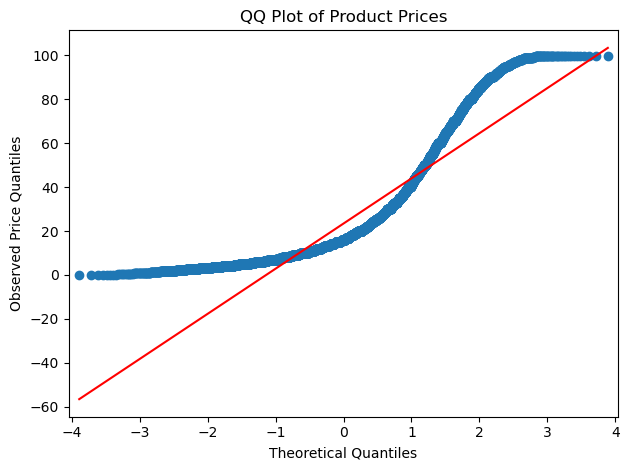

In [45]:
import statsmodels.api as sm

sm.qqplot(
    qq_price_sample,
    line="s"
)

plt.title("QQ Plot of Product Prices")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Observed Price Quantiles")
plt.tight_layout()
plt.show()

### Interpretation of the QQ Plot

The QQ plot shows that product prices do not follow a normal distribution. If prices were normally distributed, the blue observations would remain close to the red reference line. Instead, the points form a pronounced curved pattern and deviate substantially from the line.

The lower price quantiles are compressed close to zero, showing that a large proportion of products are concentrated at relatively low prices. The upper quantiles rise sharply, indicating a smaller group of considerably more expensive products. The points flatten close to £100 because global price outliers above the IQR upper boundary of approximately £99.99 were removed before constructing the plot.

Therefore, removing the global outliers did not make the price distribution normal. Product prices remain positively skewed and bounded by the filtering threshold. For analyses that assume normality, a logarithmic price transformation, robust statistics or non-parametric methods may be more suitable.

---

## Business-Centric Summary of Findings

### 1. Best-seller performance differs across categories

Best-seller proportions were calculated for all 296 product categories. For readability, only the ten highest-ranking categories were displayed.

`Grocery` recorded the highest best-seller proportion at **5.81%**, followed by `Smart Home Security & Lighting` and `Health & Personal Care`, both at **5.77%**. Even in the leading categories, fewer than 6% of listings were classified as best sellers.

The Chi-square test found a statistically significant association between product category and best-seller status:

[
\chi^2(295)=36{,}540.20,\qquad p<0.001
]

However, Cramér’s V was only **0.122**, indicating that the strength of this association is weak. Category is therefore related to best-seller status, but category alone does not strongly determine whether a product becomes a best seller.

**Business implication:** Amazon sellers should consider category-specific demand when selecting products, but should not depend on category alone. Brand strength, product quality, reviews, price competitiveness, availability, advertising and customer trust may also influence best-seller performance.

### 2. Typical prices differ across product categories

After removing global price outliers using the IQR method, clear differences remained between category price distributions. Most products in the largest categories were concentrated below approximately £20, while several categories contained wider distributions and higher typical prices.

Across all categories, `Desktop PCs` had the highest median price at **£74.00**, followed by `Boxing Shoes` at **£69.79** and `Tablets` at **£69.00**. Among the ten categories with the largest listing counts, `Sports & Outdoors` had the highest average price, while `Manicure & Pedicure Products` had the lowest.

**Business implication:** A single pricing strategy would not be suitable for every category. Higher-value technology and specialist categories may support premium pricing, while categories concentrated at lower prices may require greater emphasis on sales volume, competitive pricing and cost efficiency.

### 3. Customer ratings are generally high but contain low-rating outliers

After excluding products without a recorded rating, most rating distributions were concentrated between approximately **4 and 5 stars**. Among the ten largest categories displayed, `Handmade Clothing, Shoes & Accessories` had the highest median rating, close to 5 stars.

All displayed categories contained potential low-rating outliers, including ratings close to 1 star. These observations may represent genuine negative customer experiences and should not automatically be treated as data errors.

**Business implication:** Businesses should investigate low-rated products through review text, return information, product-quality checks and seller-performance data. Addressing recurring causes of dissatisfaction may improve customer experience more effectively than focusing only on overall average ratings.

### 4. Price has virtually no practical relationship with customer rating

The Pearson correlation between product price and rating was:

[
r=0.0067,\qquad p=1.08\times10^{-12}
]

The relationship is statistically significant because of the very large dataset, but its strength is practically negligible. The scatterplot confirms that similarly rated products occur across many price levels and that expensive products do not consistently receive better ratings.

The heatmap also showed that all relationships between the analysed numerical variables were weak. The strongest non-diagonal correlation was only **0.10**, between `reviews` and `boughtInLastMonth`.

**Business implication:** Raising or lowering price alone is unlikely to improve customer ratings. Ratings are more likely to depend on factors such as product quality, accuracy of descriptions, delivery experience, customer expectations and after-sales support.

### 5. Product prices are not normally distributed

The QQ plot confirms that the filtered price distribution remains strongly non-normal and positively skewed. Lower-priced products dominate the dataset, while fewer products occupy the higher end of the retained price range.

**Business implication:** Mean prices should be interpreted cautiously because they can be affected by relatively expensive products. Medians, quartiles and category-specific distributions may provide more reliable information for pricing decisions. Statistical modelling may also benefit from transforming prices or using methods that do not require normally distributed data.

### Overall Conclusion

Amazon UK product performance varies by category, but category alone has limited explanatory power. Best-seller status is statistically associated with category, although the relationship is weak. Product prices differ substantially across categories, yet price has almost no meaningful relationship with customer rating.

The strongest business opportunity is therefore not simply to increase prices or enter a high-performing category. Businesses should combine category selection and pricing analysis with product quality, customer-review patterns, demand, competition, marketing and seller-performance information before making commercial decisions.
